In [1]:
pwd

'/Users/student/functional_group_finder'

In [1]:
cd efgs_test/

/Users/student/functional_group_finder/efgs_test


In [2]:
pwd

'/Users/student/functional_group_finder/efgs_test'

In [3]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
#from chembl_structure_pipeline import standardizer as sdz
from datetime import datetime
from IPython.display import Image
from PIL import Image as pilImage
from PIL import ImageDraw, ImageFont
from rdkit.Chem.Draw import rdMolDraw2D
import pandas as pd
import io
import efgs
from efgs import *

In [6]:
def mindex(mol):
    # Utility function to draw molecule with idx
    for atom in mol.GetAtoms():
        try:
            atom.SetAtomMapNum(atom.GetIdx())
        except:
            None
    return mol


def demindex(mol):
    # Utility function to return mindex-ed molecule to normal
    for atom in mol.GetAtoms():
        atom.ClearProp('molAtomMapNumber')
    return mol


def molimg(x):
    # Utility function to draw image of labeled mol from PNG binary string
    try:
        return pilImage.open(io.BytesIO(x))
    except:
        return None
    

def img_grid(images, titles = None, num_columns = 5,font = "arial.ttf", font_size = 18, title_height = 30, cell_width = 300, cell_height = 300, bg_color = (255, 255, 255)):
    """
    Creates a grid of images with optional titles under each image.

    Parameters:
    - images (list): List of PIL Image objects.
    - titles (list, optional): List of titles as strings for each image. If None, no titles will be added.
    - num_columns (int): Number of columns in the grid.
    - font_sizes: Font size of titles (if provided).
    - title_height: Height of titles (if provieded).
    - cell_width (int): Width of each image cell.
    - cell_height (int): Height of each image cell (not including title space).
    - bg_color (tuple): Background color as an RGB tuple.

    Returns:
    - PIL Image object containing the image grid.
    """
    # Set title height if titles are provided; otherwise, set to zero
    title_height = title_height if titles else 0
    cell_height_with_title = cell_height + title_height + 2

    # Calculate grid dimensions
    num_images = len(images)
    num_rows = (num_images + num_columns - 1) // num_columns  # Round up for last row

    # Create a blank background image for the grid
    grid_width = num_columns * cell_width
    grid_height = num_rows * cell_height_with_title
    grid_image = pilImage.new("RGB", (grid_width, grid_height), bg_color)

    # Set up font for titles if needed
    if titles:
        try:
            font = ImageFont.truetype(font, font_size)  # Change font and size as desired
        except IOError:
            font = ImageFont.load_default()

    # Iterate through each cell in the grid
    for i in range(num_rows * num_columns):
        row = i // num_columns
        col = i % num_columns
        x = col * cell_width
        y = row * cell_height_with_title

        if i < num_images:
            # Resize the image to fit in the cell
            img_resized = images[i].resize((cell_width, cell_height))
            grid_image.paste(img_resized, (x, y))

            # Draw title if provided
            if titles and i < len(titles):
                draw = ImageDraw.Draw(grid_image)
                title = titles[i]

                # Calculate title position and center it
                text_bbox = draw.textbbox((0, 0), title, font=font)
                text_width = text_bbox[2] - text_bbox[0]
                title_x = x + (cell_width - text_width) // 2  # Center title horizontally
                title_y = y + cell_height  # Position directly beneath the image

                # Draw title text
                draw.text((title_x, title_y), title, fill="black", font=font)
        else:
            # Leave blank space if no image for this cell
            blank_cell = pilImage.new("RGB", (cell_width, cell_height), bg_color)
            grid_image.paste(blank_cell, (x, y))

    return grid_image

In [9]:
ertl_smis = [
    'Cc1nc(NS(=O)(=O)c2ccc(N)cc2)nc(C)c1', 
    'NC(=N)c1ccc(C=Cc2ccc(cc2O)C(=N)N)cc1', 
    'CC(=O)Nc1nnc(s1)S(=O)(=O)N',
    'NS(=O)(=O)c1cc2c(NCNS2(=O)=O)cc1Cl',
    'CNC1=Nc2ccc(Cl)cc2C(=N(=O)C1)c3ccccc3',
    'Cc1onc(c1C(=O)NC2C3SC(C)(C)C(N3C2=O)C(=O)O)c4ccccc4',
    'Clc1ccccc1C2=NCC(=O)Nc3ccc(cc23)N(=O)=O',
    'COc1cc(cc(C(=O)NCC2CCCN2CC=C)c1OC)S(=O)(=O)N',
    'Cc1ccc(Cl)c(Nc2ccccc2C(=O)O)c1Cl',
    'Clc1ccc2Oc3ccccc3N=C(N4CCNCC4)c2c1',
    'FC(F)(F)CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13',
    'OCC1OC(CC1O)n2cnc3C(O)CNC=Nc32',
    'CCNC1CC(C)S(=O)(=O)c2sc(cc12)S(=O)(=O)N',
    'CC(O)C1C2C(C)C(=C(N2C1=O)C(=O)O)SC3CNC(C3)C(=O)N(C)C',
    'CC1CN(CC(C)N1)c2c(F)c(N)c3c(=O)c(cn(C4CC4)c3c2F)C(=O)O',
    'CC(=CCC1C(=O)N(N(C1=O)c2ccccc2)c3ccccc3)C',
    'Clc1ccc2N=C3NC(=O)CN3Cc2c1Cl',
    'CC(=O)NC1C(NC(=N)N)C=C(OC1C(O)C(O)CO)C(=O)O',
    'CC(O)C(O)C1CNc2nc(N)nc(O)c2N1',
    'NC1CCCCN(C1)c2c(Cl)cc3c(=O)c(cn(C4CC4)c3c2Cl)C(=O)O',
]

In [29]:
ertl_smis[0]

'Cc1nc(NS(=O)(=O)c2ccc(N)cc2)nc(C)c1'

In [7]:
efgs

<module 'efgs' from '/Users/student/functional_group_finder/efgs_test/efgs.py'>

In [12]:
test_example = "N#CC1=CC=CC=C1"

In [13]:
efgs.get_dec_fgs(Chem.MolFromSmiles(test_example))

(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x00\xfa\x08\x02\x00\x00\x00\x94\x0f\xed\xa4\x00\x00\x00\x06bKGD\x00\xff\x00\xff\x00\xff\xa0\xbd\xa7\x93\x00\x00 \x00IDATx\x9c\xed\xddw|\x14u\xde\x07\xf0\xef\xcc\xf6\x92\xdeH \xa1\'\xa1\x85@\x1a& \xd5\x07\xd1x\xa7w\xc0\xe3\x1d&\xdc\x9d\x0f\xb1\'\xa0<\xe6\xb0\x85\x92(\x8aB\x02\xea\x1d\xa2h\x90S\x01\xbd\xf3\x00\x11/\x91"\x98J\xa8\x81$\xa4@\n\xe9u7\xdb\xcb<\x7f\x8c\xe6\x81\x00afKf\xb3\xf9\xbe\xff\xf0\xf5\xbacg\xf6\xbb0\x9f\xfd\xcd\xfe\xda\x10\x14E\x01B\x88;$\xd7\x05 4\xdca\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8ea\x08\x11\xe2\x18\x86\x10!\x8e9y\x08\x7f\xf8\xe1\x87G\x1f}\xf4\xf7\xbf\xff}kk+\xd7\xb5 tg\x84\xb3ny\xd8\xd8\xd8\xb8t\xe9\xd2\xfc\xfc|\xfa\x7f\xf2x\xbc\x95+W~\xf4\xd1G<\x1e\x8f\xdb\xc2\x10\xea\xc7\t[

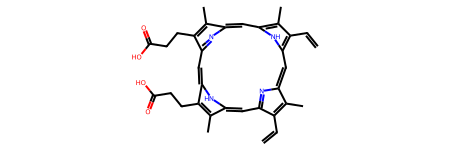

In [17]:
Chem.MolFromSmiles(test_example)

In [4]:
functional_group_etrl = {
    'cyanide' : 'C#N',
    'carbonyl' : 'O=[Car]',
    'SH' : 'S[R]',
    'F' : 'F[R]',
    'Methoxy' : 'O=C([R])O[R]',
    'Br' : '[R]Br',
    'aliphatic-Amino' : 'N[Cal]',
    'aromatic-Amino' : 'N[Car]',
    'Amide' : '',
    'Acetate' : 'O=C(O)[R]',
    'Sulfonic Acid' : '',
    'Amine' : '[R]N[R]', #amine but maybe within a ring
    'Cl' : 'Cl[R]',
    'I' : '[R]I',
    'aliphatic-OH' : 'O[Cal]', #the OH is attached to aliphatic carbon
    'aromatic-OH' : 'O[Car]' #the OH is attached to aromatic carbon
}

In [31]:
test_example_2 = "OC1=C(C(O)=O)C(Cl)=C(C#N)C(N)=C1Cl"

In [32]:
example_result = efgs.get_dec_fgs(Chem.MolFromSmiles(test_example_2))

In [33]:
example_result[2]

['O[Car]', 'O=C(O)[R]', 'Cl[R]', 'C#N', 'N[Car]', 'Cl[R]']

In [36]:
results = [(k, example_result[2].count(v)) for k, v in functional_group_etrl.items() if example_result[2].count(v) > 0]
results


[('cyanide', 1),
 ('aromatic-Amino', 1),
 ('Acetate', 1),
 ('Cl', 2),
 ('aromatic-OH', 1)]

In [5]:
coconut_filtered_df = pd.read_csv('/Users/student/database_filtering/Planning/coconut_purchasable_filtered.csv')

In [6]:
coconut_filtered_df

,identifier,canonical_smiles,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,np_classifier_class,np_classifier_is_glycoside,organisms,collections,dois,synonyms,cas,collections_list,functional_group,functional_group_count
0,CNP0214016.1,COC1=CC2=CC(=C1Cl)N(C)C(=O)C[C@H](OC(=O)[C@H](...,InChI=1S/C34H46ClN3O10/c1-18-11-10-12-26(45-9)...,WKPWGQKGSOKKOO-RSFHAFMBSA-N,MAYTANSINE,"[(1~{S},2~{R},3~{S},5~{S},6~{S},16~{E},18~{E},...",4,94,48,692.21,...,Ansa macrolides,False,Maytenus buchananii|Maytenus confertiflorus|Ma...,ChEBI NPs|ChEMBL NPs|KNApSaCK|NCI DTP data|Sup...,NaN,Maitansine|Maytansine USAN|Maitansinum|NSC-153...,35846-53-8,"['ChEBI NPs', 'ChEMBL NPs', 'KNApSaCK', 'NCI D...",Methoxy;Amide;Amine;Cl;OH,5
1,CNP0116456.1,C[C@H]1O[C@@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H...,InChI=1S/C47H74O19/c1-20-41(64-36-16-30(50)42(...,OBATZBGFDSVCJD-LALPQLPRSA-N,deslanoside,"3-[(3~{S},5~{R},8~{R},9~{S},10~{S},12~{R},13~{...",4,140,66,943.09,...,Cardenolides,True,Aria arguta|Atropa belladona|Begonia glabra|Co...,CMAUP (cCollective molecular activities of use...,NaN,17598-65-1|Desacetyllanatoside C|Cedilanid-D|D...,17598-65-1,['CMAUP (cCollective molecular activities of u...,OH,1
2,CNP0597189.0,CN1C(=O)C2=C(N=CN2)N(C)C1=O,InChI=1S/C7H8N4O2/c1-10-5-4(8-3-9-5)6(12)11(2)...,ZFXYFBGIUFBOJW-UHFFFAOYSA-N,theophylline,"1,3-dimethyl-7~{H}-purine-2,6-dione",5,21,13,180.17,...,Purine alkaloids,False,Camellia assamica|Camellia irrawadiensisia|Cam...,BitterDB|ChEBI NPs|ChEMBL NPs|DrugBankNP|FooDB...,10.1002/9780470744307.gat218|10.1002/biuz.1984...,58-55-9|1|3-Dimethylxanthine|Elixophyllin|Theo...,58-55-9|75448-53-2|58-55-9 (ANHYDROUS)|50857-7...,"['BitterDB', 'ChEBI NPs', 'ChEMBL NPs', 'DrugB...",Amine,1
3,CNP0108720.0,CCCCCCCCCCCCCCCC(=O)OCC=C(C)C=CC=C(C)C=CC1=C(C...,InChI=1S/C36H60O2/c1-7-8-9-10-11-12-13-14-15-1...,VYGQUTWHTHXGQB-UHFFFAOYSA-N,Retinol palmitate,"[3,7-dimethyl-9-(2,6,6-trimethylcyclohexen-1-y...",5,98,38,524.87,...,Wax monoesters,False,Fagopyrum esculentum|Homo sapiens,CMAUP (cCollective molecular activities of use...,10.1007/s00394-006-0612-0|10.1016/b978-0-12-37...,Retinyl (palmitate)|Vitamin A palmitate;Retino...,NaN,['CMAUP (cCollective molecular activities of u...,none,0
4,CNP0339669.0,NC(N)=NC1=NC(CSCCC(N)=NS(N)(=O)=O)=CS1,"InChI=1S/C8H15N7O2S3/c9-6(15-20(12,16)17)1-2-1...",XUFQPHANEAPEMJ-UHFFFAOYSA-N,famotidine,3-[(2-guanidinothiazol-4-yl)methylsulfanyl]-~{...,3,35,20,337.46,...,NaN,False,NaN,BitterDB|ChEMBL NPs|DrugBankNP|FooDB|Super Nat...,NaN,76824-35-6|PEPCID|Famotidinum|Famotidina|Gastr...,76824-35-6,"['BitterDB', 'ChEMBL NPs', 'DrugBankNP', 'FooD...",none,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22814,CNP0236594.0,O=C(O)CC(=CC1=CC=CC=C1)C(=O)O,InChI=1S/C11H10O4/c12-10(13)7-9(11(14)15)6-8-4...,KYILORDWJFEQBS-UHFFFAOYSA-N,2-benzylidenebutanedioic acid,2-benzylidenebutanedioic acid,2,25,15,206.20,...,NaN,False,NaN,TCMDB-Taiwan (Traditional Chinese Medicine dat...,NaN,Butanedioic acid| (phenylmethylene)-|2-benzyli...,NaN,['TCMDB-Taiwan (Traditional Chinese Medicine d...,OH,1
22815,CNP0175994.10,CC[C@H](C)C(=O)N[C@@H]1CCCN1C(=O)[C@@H]1[C@@H]...,InChI=1S/C38H44N2O9/c1-7-22(2)34(42)39-30-14-1...,HCNJABPCRMQADU-GWLUIEKISA-N,NaN,"[(1~{R},9~{R},10~{S},11~{R},12~{S})-1-hydroxy-...",1,93,49,672.78,...,NaN,False,NaN,TCMDB-Taiwan (Traditional Chinese Medicine dat...,NaN,NaN,NaN,['TCMDB-Taiwan (Traditional Chinese Medicine d...,Methoxy;Acetate;OH,3
22816,CNP0154990.15,COC1=CC(O)=C2C(=O)C(O[C@H]3O[C@H](CO)[C@H](O)[...,InChI=1S/C22H22O12/c1-31-9-5-12(26)15-13(6-9)3...,PHEWILLIAJUBQE-HTFSQMSJSA-N,NaN,"2-(3,4-dihydroxyphenyl)-5-hydroxy-7-methoxy-3-...",1,56,34,478.41,...,Flavonols,True,NaN,TCMDB-Taiwan (Traditional Chinese Medicine dat...,NaN,NaN,NaN,['TCMDB-Taiwan (Traditional Chinese Medicine d...,Methoxy;OH,2
22817,CNP0237115.12,O=C1C(O[C@@H]2O[C@H](CO)[C@H](O)[C@@H](O)[C@H]...,InChI=1S/C21H20O13/c22-5-12-15(28)17(30)18(31)

In [7]:
coconut_filtered_smi = dict(zip(coconut_filtered_df['identifier'], coconut_filtered_df['canonical_smiles']))

In [8]:
coconut_filtered_smi

{'CNP0214016.1': 'COC1=CC2=CC(=C1Cl)N(C)C(=O)C[C@H](OC(=O)[C@H](C)N(C)C(C)=O)[C@]1(C)O[C@H]1[C@H](C)[C@@H]1C[C@@](O)(NC(=O)O1)[C@H](OC)/C=C/C=C(\\C)C2',
 'CNP0116456.1': 'C[C@H]1O[C@@H](O[C@H]2CC[C@@]3(C)[C@H](CC[C@@H]4[C@@H]3C[C@@H](O)[C@]3(C)[C@@H](C5=CC(=O)OC5)CC[C@]43O)C2)C[C@H](O)[C@@H]1O[C@H]1C[C@H](O)[C@H](O[C@H]2C[C@H](O)[C@H](O[C@@H]3O[C@H](CO)[C@@H](O)[C@H](O)[C@H]3O)[C@@H](C)O2)[C@@H](C)O1',
 'CNP0597189.0': 'CN1C(=O)C2=C(N=CN2)N(C)C1=O',
 'CNP0108720.0': 'CCCCCCCCCCCCCCCC(=O)OCC=C(C)C=CC=C(C)C=CC1=C(C)CCCC1(C)C',
 'CNP0339669.0': 'NC(N)=NC1=NC(CSCCC(N)=NS(N)(=O)=O)=CS1',
 'CNP0248684.1': 'CCCCC[C@H](O)/C=C/[C@@H]1[C@@H](C/C=C\\CCCC(=O)O)[C@@H](O)C[C@H]1O',
 'CNP0347795.1': 'C[C@H](CCC(=O)O)[C@H]1CC[C@H]2[C@@H]3[C@H](O)C[C@@H]4C[C@H](O)CC[C@]4(C)[C@H]3C[C@H](O)[C@]12C',
 'CNP0226604.2': 'OC[C@H]1O[C@@H](O[C@H]2[C@H](O)[C@@H](O)[C@H](O)O[C@@H]2CO)[C@H](O)[C@@H](O)[C@H]1O',
 'CNP0556292.1': 'O=C(CC1=CC=CS1)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[N+]3=CC=CC=C3)CS[C@H]12',
 'CNP0261058.

In [8]:
def split_dict(d, n=5):
    items = list(d.items())
    size = len(items) // n
    remainder = len(items) % n

    out = []
    start = 0
    for i in range(n):
        extra = 1 if i < remainder else 0
        end = start + size + extra
        out.append(dict(items[start:end]))
        start = end

    return out

In [9]:
parts = split_dict(coconut_filtered_smi, 5)

d1, d2, d3, d4, d5 = parts

In [10]:
from tqdm import tqdm
import psutil, os

coconut_filtered_functional_groups = {}
# Process molecules in batches

In [18]:
d1_attach = {}
for k, v in tqdm(d1.items(), desc="Processing part 1/5"):
        try:
            etrl_result = efgs.get_dec_fgs(Chem.MolFromSmiles(v))
            results = [(fg_name, etrl_result[2].count(fg_smarts)) for fg_name, fg_smarts in functional_group_etrl.items() if etrl_result[2].count(fg_smarts) > 0]
            coconut_filtered_functional_groups[k] = results
        except Exception as e:
            print(f"Error processing molecule {k}: {e}")
            coconut_filtered_functional_groups[k] = 'failed'
            continue

Processing part 1/5:  11%|█         | 486/4564 [00:04<00:37, 108.49it/s]

Error processing molecule CNP0509474.0: cannot access local variable 'col' where it is not associated with a value
Error processing molecule CNP0529065.0: cannot access local variable 'col' where it is not associated with a value


Processing part 1/5:  14%|█▍        | 640/4564 [00:06<00:35, 110.36it/s]

Error processing molecule CNP0564418.0: cannot access local variable 'col' where it is not associated with a value


Processing part 1/5:  18%|█▊        | 841/4564 [00:08<00:35, 104.93it/s]

Error processing molecule CNP0566975.0: cannot access local variable 'col' where it is not associated with a value


Processing part 1/5:  19%|█▉        | 864/4564 [00:08<00:38, 95.98it/s] 

Error processing molecule CNP0569557.0: cannot access local variable 'col' where it is not associated with a value
Error processing molecule CNP0539310.0: cannot access local variable 'col' where it is not associated with a value


Processing part 1/5: 100%|██████████| 4564/4564 [00:51<00:00, 88.03it/s] 


In [19]:
d2_attach = {}
for k, v in tqdm(d2.items(), desc="Processing part 2/5"):
        try:
            etrl_result = efgs.get_dec_fgs(Chem.MolFromSmiles(v))
            results = [(fg_name, etrl_result[2].count(fg_smarts)) for fg_name, fg_smarts in functional_group_etrl.items() if etrl_result[2].count(fg_smarts) > 0]
            coconut_filtered_functional_groups[k] = results
        except Exception as e:
            print(f"Error processing molecule {k}: {e}")
            coconut_filtered_functional_groups[k] = 'failed'
            continue

Processing part 2/5:  90%|█████████ | 4122/4564 [00:50<00:05, 87.43it/s] 

Error processing molecule CNP0504902.0: cannot access local variable 'col' where it is not associated with a value


[16:13:24] SMILES Parse Error: syntax error while parsing: Se]
[16:13:24] SMILES Parse Error: Failed parsing SMILES 'Se]' for input: 'Se]'
Processing part 2/5:  91%|█████████ | 4140/4564 [00:50<00:05, 76.09it/s]

Error processing molecule CNP0565859.0: Python argument types in
    rdkit.Chem.rdmolfiles.MolToSmiles(NoneType)
did not match C++ signature:
    MolToSmiles(RDKit::ROMol mol, bool isomericSmiles=True, bool kekuleSmiles=False, int rootedAtAtom=-1, bool canonical=True, bool allBondsExplicit=False, bool allHsExplicit=False, bool doRandom=False)
    MolToSmiles(RDKit::ROMol mol, RDKit::SmilesWriteParams params)


Processing part 2/5:  91%|█████████ | 4161/4564 [00:50<00:04, 87.98it/s]

Error processing molecule CNP0559134.0: cannot access local variable 'col' where it is not associated with a value


Processing part 2/5: 100%|██████████| 4564/4564 [00:56<00:00, 81.25it/s]


In [11]:
d3_attach = {}
for k, v in tqdm(d3.items(), desc="Processing part 3/5"):
        try:
            etrl_result = efgs.get_dec_fgs(Chem.MolFromSmiles(v))
            if etrl_result is None:
                print(f"Error processing molecule VALUEERROR {k}: {e}")
                coconut_filtered_functional_groups[k] = 'failed'
                continue
            results = [(fg_name, etrl_result[2].count(fg_smarts)) for fg_name, fg_smarts in functional_group_etrl.items() if etrl_result[2].count(fg_smarts) > 0]
            coconut_filtered_functional_groups[k] = results
        except Exception as e:
            print(f"Error processing molecule {k}: {e}")
            coconut_filtered_functional_groups[k] = 'failed'
            continue

Processing part 3/5:  43%|████▎     | 1951/4564 [00:26<00:35, 72.88it/s]

: 

In [ ]:
d4_attach = {}
for k, v in tqdm(d4.items(), desc="Processing part 4/5"):
        try:
            etrl_result = efgs.get_dec_fgs(Chem.MolFromSmiles(v))
            results = [(fg_name, etrl_result[2].count(fg_smarts)) for fg_name, fg_smarts in functional_group_etrl.items() if etrl_result[2].count(fg_smarts) > 0]
            coconut_filtered_functional_groups[k] = results
        except Exception as e:
            print(f"Error processing molecule {k}: {e}")
            coconut_filtered_functional_groups[k] = 'failed'
            continue

In [ ]:
d5_attach = {}
for k, v in tqdm(d5.items(), desc="Processing part 5/5"):
        try:
            etrl_result = efgs.get_dec_fgs(Chem.MolFromSmiles(v))
            results = [(fg_name, etrl_result[2].count(fg_smarts)) for fg_name, fg_smarts in functional_group_etrl.items() if etrl_result[2].count(fg_smarts) > 0]
            coconut_filtered_functional_groups[k] = results
        except Exception as e:
            print(f"Error processing molecule {k}: {e}")
            coconut_filtered_functional_groups[k] = 'failed'
            continue

In [9]:
import numpy as np

In [ ]:
np.arry()